<div align="center">

<h1> <b> RELATIVISTIC KINEMATICS OF PARTICLES </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Juan Esteban Henao Duque <br>
Cristian Camilo Vergara Restrepo <br>
Sebastián Eladio Mena Torres</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---


## Introducción

Este notebook aborda dos problemas clásicos de la cinemática relativista de partículas subatómicas.

En la primera parte se construye una **calculadora relativista**: a partir de una única cantidad conocida de una partícula (su velocidad, su energía total, su energía cinética, la razón entre su masa relativista y su masa en reposo, o su momento relativista) se determinan todas las demás cantidades cinemáticas. El cálculo se apoya en las relaciones estándar de la relatividad especial (Einstein, 1905):

$$E = \gamma m_0 c^2, \qquad p = \gamma m_0 v, \qquad E^2 = (pc)^2 + (m_0c^2)^2, \qquad \gamma = \frac{1}{\sqrt{1-(v/c)^2}}$$

donde $m_0$ es la masa en reposo de la partícula, $v$ su velocidad, $c$ la velocidad de la luz en el vacío y $\gamma$ el factor de Lorentz. La calculadora permite trabajar tanto con partículas comunes (electrón, protón, neutrón, deuterón, partícula alfa) como con cualquier otra partícula del modelo estándar, tomando su masa en reposo de una tabla de referencia.

En la segunda parte se compara, para varias partículas, la energía cinética relativista real $T_R$ con la energía cinética que predeciría la mecánica clásica, $T_C = \tfrac{1}{2}m_0v^2$, evaluada con la velocidad relativista real correspondiente a $T_R$. Esta comparación ilustra un resultado central de la relatividad especial: mientras que $T_R$ crece sin límite a medida que $v \to c$, la expresión clásica satura en $\tfrac{1}{2}m_0c^2$, de modo que ambas descripciones solo coinciden en el límite no relativista ($v \ll c$).


## 1. Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# tabulate no es una dependencia estándar de Python; si no está disponible,
# se define una alternativa mínima para no interrumpir la ejecución del notebook.
try:
    from tabulate import tabulate
except ImportError:
    def tabulate(data, headers=(), showindex=False):
        filas = [list(headers)] if headers else []
        for i, fila in enumerate(data):
            filas.append(([str(i)] if showindex else []) + [str(x) for x in fila])
        anchos = [max(len(f[j]) for f in filas) for j in range(len(filas[0]))]
        return "\n".join(
            "  ".join(val.ljust(anchos[j]) for j, val in enumerate(fila))
            for fila in filas
        )


## 2. Constantes físicas fundamentales

Se define la velocidad de la luz en el vacío y las masas en reposo de las partículas más usadas en este notebook, tanto en kilogramos (Sistema Internacional) como en MeV/c² (unidades naturales de la física de partículas). Los valores corresponden al ajuste CODATA 2018 de las constantes fundamentales (Tiesinga et al., 2021).

In [2]:
C = 299792458.0  # velocidad de la luz en el vacío, m/s (valor exacto por definición del SI)

# Masas en reposo, en kilogramos
me = 9.1093837015e-31   # electrón
mp = 1.67262192369e-27  # protón
mn = 1.67492749804e-27  # neutrón
ma = 6.6446573357e-27   # partícula alfa
md = 3.3435837724e-27   # deuterón
u  = 1.66053906660e-27  # unidad de masa atómica

# Masas en reposo equivalentes, en MeV/c^2
mee = 0.51099895000   # electrón
mpe = 938.27208816    # protón
mne = 939.56542052    # neutrón
mae = 3727.3794066    # partícula alfa
mde = 1875.61294257   # deuterón
ue  = 931.49410242    # unidad de masa atómica


## 3. Tabla de referencia de partículas subatómicas

Las siguientes tablas recogen la masa en reposo, en MeV/c², de las partículas elementales y compuestas más comunes del modelo estándar, organizadas por familia: quarks, leptones, bosones de norma y de Higgs, mesones y bariones. Estos valores permiten calcular las cantidades cinemáticas relativistas de cualquier partícula que no esté entre las cinco predefinidas en la calculadora (electrón, protón, neutrón, deuterón y partícula alfa).

Los valores siguen la Review of Particle Physics del Particle Data Group (Navas et al., 2024), complementada, para las partículas no incluidas explícitamente en dicha revisión, con la tabla de partículas de Wikipedia (referencia secundaria; ver sección de referencias).

In [3]:
# Quarks: masas "current-quark" en el esquema MS-bar a la escala mu = 2 GeV
# (la masa del quark top corresponde a su masa "pole", obtenida cinemáticamente,
# que sigue un esquema distinto al de los quarks más livianos).
quarks = [['up', 2.16],
          ['down', 4.67],
          ['charm', 1270],
          ['strange', 93.4],
          ['top', 172500],
          ['bottom', 4180]]

leptones = [['Positrón', 0.511],
            ['Muón', 105.6584],
            ['Antimuón', 105.6584],
            ['Tauón', 1776.86],
            ['Antitauón', 1776.86]]

bosones = [['Bosón W', 80369.2],
           ['Bosón Z', 91188.0],
           ['Bosón de Higgs', 125200]]

mesones = [['Pion cargado', 139.6],
           ['Pion neutro', 135.0],
           ['Kaón cargado', 493.7],
           ['Kaón neutro', 497.7],
           ['Kaón corto', 497.7],
           ['Kaón largo', 497.7],
           ['Eta', 547.75],
           ['Eta prima', 957.78],
           ['Rho cargado', 776],
           ['Omega neutra', 782.65],
           ['Phi', 1019.46],
           ['D cargado', 1869.3],
           ['D neutro', 1864.5],
           ['D extraño', 1968.2],
           ['B cargado', 5279.0],
           ['B neutro', 5279.4],
           ['B extraño', 5369.6],
           ['B encantado', 6274.47],
           ['Upsilon', 9460.30]]

bariones = [['Delta doble positiva', 1232],
            ['Delta positiva', 1232],
            ['Delta neutra', 1232],
            ['Delta negativa', 1232],
            ['Lambda neutra', 1115.68],
            ['Sigma positiva', 1189.37],
            ['Sigma negativa', 1192.64],
            ['Xi neutra', 1314.83],
            ['Xi negativa', 1321.31],
            ['Omega', 1672.45],
            ['Omega encantada', 2697.5],
            ['Xi positiva encantada', 2468],
            ['Xi neutra encantada', 2471],
            ['Lambda encantada', 2284.9],
            ['Xi doble encantada', 3519],
            ['Lambda inferior', 5624]]


## 4. Utilidades de conversión de unidades

Las funciones físicas de este notebook trabajan internamente en unidades del Sistema Internacional (kilogramos, metros, segundos, joules). Las siguientes funciones convierten entre el SI y las unidades en que habitualmente se reportan las cantidades de física de partículas (MeV, MeV/c y MeV/c²).

Las equivalencias se derivan de la definición exacta del electronvoltio, $1\ \text{eV} = 1.602176634\times10^{-19}\ \text{J}$ (valor exacto, fijado por la definición del SI de la carga elemental).

In [4]:
MEV_A_JOULE = 1.602176634e-13        # J por MeV (exacto)
MEV_C_A_KG_M_S = MEV_A_JOULE / C     # kg m/s por unidad de MeV/c
MEV_A_KG = MEV_A_JOULE / C**2        # kg por unidad de MeV/c^2


def mev_a_joule(valor_mev):
    """Convierte una energía dada en MeV a joules."""
    return valor_mev * MEV_A_JOULE


def joule_a_mev(valor_joule):
    """Convierte una energía dada en joules a MeV."""
    return valor_joule / MEV_A_JOULE


def mev_c_a_kg_m_s(valor_mev_c):
    """Convierte un momento dado en unidades de MeV/c a kg·m/s."""
    return valor_mev_c * MEV_C_A_KG_M_S


def kg_m_s_a_mev_c(valor_si):
    """Convierte un momento dado en kg·m/s a unidades de MeV/c."""
    return valor_si / MEV_C_A_KG_M_S


def mev_a_kg(valor_mev):
    """Convierte una masa en reposo dada en MeV/c^2 a kilogramos."""
    return valor_mev * MEV_A_KG


## 5. Cinemática relativista: de una propiedad conocida a todas las demás

Dada la masa en reposo $m_0$ de una partícula y **una** de las siguientes cantidades, la velocidad $v$ se despeja de las relaciones relativistas estándar:

| Cantidad conocida | Relación empleada |
|---|---|
| Velocidad $v$ | (dato directo) |
| Razón $m/m_0=\gamma$ | $v = c\sqrt{1-1/\gamma^2}$ |
| Momento relativista $p$ | $v = pc^2/E$, con $E=\sqrt{(pc)^2+(m_0c^2)^2}$ |
| Energía cinética $K$ | $\gamma = 1+K/(m_0c^2)$, luego $v=c\sqrt{1-1/\gamma^2}$ |
| Energía total $E$ | $v = c\sqrt{1-(m_0c^2/E)^2}$ |

Una vez conocida $v$, las demás cantidades cinemáticas se obtienen de:

$$m=\gamma m_0, \qquad p=\gamma m_0 v, \qquad K=(\gamma-1)m_0c^2, \qquad E=m_0c^2+K$$

In [5]:
def velocidad_relativista(propiedad, valor, m0):
    """
    Calcula la velocidad de una partícula relativista, en m/s, a partir de
    una única propiedad física conocida.

    Parámetros
    ----------
    propiedad : int
        Código de la cantidad conocida:
        1 -> velocidad (el valor ya está en m/s);
        2 -> energía total E (en J);
        3 -> energía cinética K (en J);
        4 -> razón m/m0, equivalente al factor de Lorentz gamma (adimensional);
        5 -> momento relativista p (en kg·m/s).
    valor : float
        Valor numérico de la propiedad, en las unidades del SI indicadas
        arriba (o adimensional para la razón m/m0).
    m0 : float
        Masa en reposo de la partícula, en kilogramos.

    Retorna
    -------
    float
        Velocidad de la partícula, en m/s.
    """
    if propiedad == 1:
        return valor

    if propiedad == 4:
        gamma = valor
        return C * np.sqrt(1 - 1 / gamma**2)

    if propiedad == 5:
        p = valor
        E = np.sqrt((p * C)**2 + (m0 * C**2)**2)  # relación energía-momento
        return p * C**2 / E

    if propiedad == 3:
        k = valor
        gamma = 1 + k / (m0 * C**2)
        return C * np.sqrt(1 - 1 / gamma**2)

    # propiedad == 2: energía total conocida
    E = valor
    return C * np.sqrt(1 - (m0 * C**2 / E)**2)


def cantidades_relativistas(m0, v):
    """
    A partir de la masa en reposo y la velocidad de una partícula, calcula
    su masa relativista, su momento, su energía cinética y su energía total
    (todo en unidades del SI).

    Parámetros
    ----------
    m0 : float
        Masa en reposo, en kilogramos.
    v : float
        Velocidad, en m/s.

    Retorna
    -------
    tuple(float, float, float, float)
        (masa relativista en kg, momento en kg·m/s, energía cinética en J,
        energía total en J).
    """
    gamma = 1 / np.sqrt(1 - (v / C)**2)
    m = gamma * m0
    p = gamma * m0 * v
    k = (gamma - 1) * m0 * C**2
    E = m0 * C**2 + k
    return m, p, k, E


def resolver_particula(propiedad, valor_usuario, unidad, m0_kg):
    """
    Resuelve todas las cantidades cinemáticas relativistas de una partícula
    a partir de una única propiedad conocida, expresada en las unidades que
    elija el usuario.

    Parámetros
    ----------
    propiedad : int
        Código de la propiedad conocida (ver `velocidad_relativista`).
    valor_usuario : float
        Valor numérico de la propiedad, en la unidad indicada por `unidad`.
    unidad : str or None
        'MeV' si la propiedad (energía o momento) se dio en unidades de
        física de partículas; None o 'Joule'/'kg·m/s' si ya está en el SI;
        se ignora para las propiedades 1 y 4.
    m0_kg : float
        Masa en reposo de la partícula, en kilogramos.

    Retorna
    -------
    dict
        Diccionario con la velocidad (m/s y en fracción de c), la masa
        relativista, el momento y las energías cinética y total, tanto en
        unidades del SI como en MeV.
    """
    if propiedad in (2, 3) and unidad == 'MeV':
        valor_si = mev_a_joule(valor_usuario)
    elif propiedad == 5 and unidad == 'MeV':
        valor_si = mev_c_a_kg_m_s(valor_usuario)
    else:
        valor_si = valor_usuario  # ya en SI (o adimensional, o m/s)

    v = velocidad_relativista(propiedad, valor_si, m0_kg)
    m, p, k, E = cantidades_relativistas(m0_kg, v)

    return {
        'velocidad_m_s': v,
        'beta': v / C,
        'masa_relativista_kg': m,
        'momento_kg_m_s': p,
        'momento_MeV_c': kg_m_s_a_mev_c(p),
        'energia_cinetica_J': k,
        'energia_cinetica_MeV': joule_a_mev(k),
        'energia_total_J': E,
        'energia_total_MeV': joule_a_mev(E),
    }


## 6. Ejemplo de uso

Como ilustración, se calculan todas las cantidades cinemáticas de un protón cuya energía cinética es de 500 MeV.

In [6]:
resultado_ejemplo = resolver_particula(propiedad=3, valor_usuario=500, unidad='MeV', m0_kg=mp)

print(f"beta = v/c            = {resultado_ejemplo['beta']:.4f}")
print(f"momento relativista   = {resultado_ejemplo['momento_MeV_c']:.2f} MeV/c")
print(f"energia cinetica      = {resultado_ejemplo['energia_cinetica_MeV']:.2f} MeV")
print(f"energia total         = {resultado_ejemplo['energia_total_MeV']:.2f} MeV")


beta = v/c            = 0.7579
momento relativista   = 1090.08 MeV/c
energia cinetica      = 500.00 MeV
energia total         = 1438.27 MeV


## 7. Calculadora interactiva

La siguiente celda solicita, de forma interactiva, la partícula de interés y la propiedad cinemática que se conoce de ella. Si la partícula no está entre las cinco predefinidas, se toma su masa en reposo de las tablas de la sección 3.

In [7]:
# Selección de la partícula
print("Seleccione la partícula para la que desea calcular sus propiedades cinemáticas:")
print("1. Electrón\n2. Protón\n3. Neutrón\n4. Deuterón\n5. Partícula alfa\n6. Otra partícula")
particula = int(input("Elija el número de la partícula: "))

if particula == 6:
    print("\n¿A qué categoría de partículas pertenece?")
    print("1. Quarks\n2. Leptones\n3. Bosones\n4. Mesones\n5. Bariones")
    categoria = int(input("Elija el número de la categoría: "))

    tablas = {1: ('Quarks', quarks), 2: ('Leptones', leptones),
              3: ('Bosones', bosones), 4: ('Mesones', mesones), 5: ('Bariones', bariones)}
    nombre_tabla, tabla = tablas[categoria]

    print(tabulate(tabla, headers=[nombre_tabla, 'Masa en reposo (MeV/c^2)'], showindex=True))
    fila = int(input("\nEscriba el número de la fila de la partícula deseada: "))
    m0_kg = mev_a_kg(tabla[fila][1])
else:
    masas_predefinidas = {1: me, 2: mp, 3: mn, 4: md, 5: ma}
    m0_kg = masas_predefinidas[particula]

# Selección de la propiedad conocida
print("\nIngrese la propiedad que conoce de la partícula:")
print("1. Velocidad\n2. Energía total\n3. Energía cinética\n4. Relación m/m0\n5. Momento relativista")
propiedad = int(input("Elija el número de la propiedad que conoce: "))

unidad = None
if propiedad in (2, 3):
    etiqueta = 'Energía Total' if propiedad == 2 else 'Energía Cinética'
    print(f"\nIngrese las unidades de la {etiqueta}:")
    print("1. Joule\n2. MeV")
    unidad = 'Joule' if int(input(f"Elija el número de las unidades de {etiqueta}: ")) == 1 else 'MeV'
elif propiedad == 5:
    print("\nIngrese las unidades del Momento relativista:")
    print("1. kg·m/s\n2. MeV/c")
    unidad = 'kg·m/s' if int(input("Elija el número de las unidades del Momento relativista: ")) == 1 else 'MeV'

if propiedad == 1:
    valor_usuario = float(input("\nIngrese la velocidad de la partícula, en m/s: "))
elif propiedad == 4:
    valor_usuario = float(input("\nIngrese el valor de la relación m/m0: "))
else:
    valor_usuario = float(input(f"\nIngrese el valor numérico de la propiedad, en {unidad}: "))


Seleccione la partícula para la que desea calcular sus propiedades cinemáticas:
1. Electrón
2. Protón
3. Neutrón
4. Deuterón
5. Partícula alfa
6. Otra partícula
Elija el número de la partícula: 1

Ingrese la propiedad que conoce de la partícula:
1. Velocidad
2. Energía total
3. Energía cinética
4. Relación m/m0
5. Momento relativista
Elija el número de la propiedad que conoce: 4

Ingrese el valor de la relación m/m0: 2


In [8]:
resultados = resolver_particula(propiedad, valor_usuario, unidad, m0_kg)

print(f"\nVelocidad             : {resultados['velocidad_m_s']:.6e} m/s   (beta = v/c = {resultados['beta']:.6f})")
print(f"Masa relativista      : {resultados['masa_relativista_kg']:.6e} kg")
print(f"Momento relativista   : {resultados['momento_kg_m_s']:.6e} kg·m/s   ({resultados['momento_MeV_c']:.4f} MeV/c)")
print(f"Energía cinética      : {resultados['energia_cinetica_J']:.6e} J   ({resultados['energia_cinetica_MeV']:.4f} MeV)")
print(f"Energía total         : {resultados['energia_total_J']:.6e} J   ({resultados['energia_total_MeV']:.4f} MeV)")



Velocidad             : 2.596279e+08 m/s   (beta = v/c = 0.866025)
Masa relativista      : 1.821877e-30 kg
Momento relativista   : 4.730100e-22 kg·m/s   (0.8851 MeV/c)
Energía cinética      : 8.187106e-14 J   (0.5110 MeV)
Energía total         : 1.637421e-13 J   (1.0220 MeV)


## 8. Energía cinética clásica frente a energía cinética relativista

Para una partícula con energía cinética relativista real $T_R$, la velocidad correspondiente se obtiene de $\gamma = 1+T_R/m_0c^2$ y $v=c\sqrt{1-1/\gamma^2}$. La pregunta que se explora en esta sección es: **si sólo se dispusiera de la mecánica clásica, qué energía cinética se le atribuiría a una partícula que se mueve a esa velocidad real** $v$. Esa cantidad es, por definición,

$$T_C = \tfrac{1}{2}m_0v^2 = \tfrac{1}{2}m_0c^2\left[1-\left(\dfrac{m_0c^2}{T_R+m_0c^2}\right)^2\right]$$

Cuando $v\ll c$ (régimen no relativista), $T_C\to T_R$: la mecánica clásica reproduce el resultado correcto. Sin embargo, a medida que $T_R$ crece y $v\to c$, $T_R$ diverge mientras que $T_C$ tiende asintóticamente a $\tfrac{1}{2}m_0c^2$, un valor finito: la energía cinética clásica satura en lugar de crecer sin límite. Este comportamiento, presente en la mayoría de los textos de física moderna (p. ej. Krane, 2012; Serway y Jewett, 2014 — no fue posible confirmar la edición o el problema exacto de origen de este ejercicio), ilustra de forma directa el fracaso de la mecánica newtoniana a velocidades cercanas a la de la luz.

A continuación se calcula y grafica $T_C$ como función de $T_R$ para cuatro partículas de masas muy distintas (partícula alfa, partícula beta/electrón, protón y neutrón), en rangos de energía cinética comparables a su masa en reposo.

In [9]:
def energia_cinetica_clasica(m0, T_R):
    """
    Energía cinética que la mecánica clásica (T = (1/2) m0 v^2) atribuiría a
    una partícula de masa en reposo `m0`, dada su energía cinética
    relativista real `T_R`. Todas las energías y masas se expresan en las
    mismas unidades (MeV y MeV/c^2 en este notebook).

    Parámetros
    ----------
    m0 : float
        Masa en reposo de la partícula, en MeV/c^2.
    T_R : array_like
        Energía cinética relativista real, en MeV.

    Retorna
    -------
    array_like
        Energía cinética clásica T_C, en MeV.
    """
    return 0.5 * m0 * (1 - (m0 / (T_R + m0))**2)


# Rangos de energía cinética relativista (MeV), comparables a la masa en
# reposo de cada partícula para poner en evidencia el régimen relativista.
T_R_alpha = np.arange(2, 11)
T_R_beta = np.arange(1, 6)
T_R_proton_neutron = np.arange(1, 5)

T_C_alpha = energia_cinetica_clasica(mae, T_R_alpha)
T_C_beta = energia_cinetica_clasica(mee, T_R_beta)
T_C_proton = energia_cinetica_clasica(mpe, T_R_proton_neutron)
T_C_neutron = energia_cinetica_clasica(mne, T_R_proton_neutron)

razon_alpha = T_R_alpha / T_C_alpha
razon_beta = T_R_beta / T_C_beta
razon_proton = T_R_proton_neutron / T_C_proton
razon_neutron = T_R_proton_neutron / T_C_neutron


### 8.1 Comparación conjunta

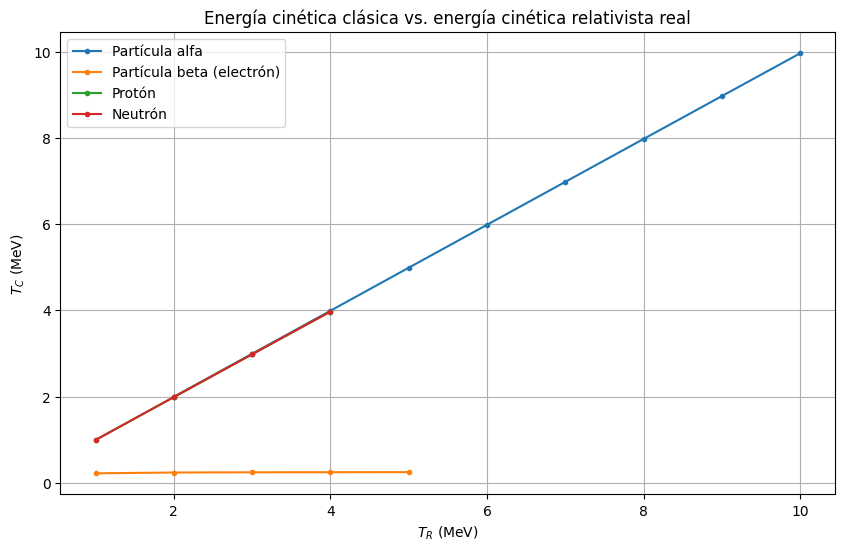

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(T_R_alpha, T_C_alpha, marker='.', label='Partícula alfa')
plt.plot(T_R_beta, T_C_beta, marker='.', label='Partícula beta (electrón)')
plt.plot(T_R_proton_neutron, T_C_proton, marker='.', label='Protón')
plt.plot(T_R_proton_neutron, T_C_neutron, marker='.', label='Neutrón')

plt.xlabel('$T_R$ (MeV)')
plt.ylabel('$T_C$ (MeV)')
plt.title('Energía cinética clásica vs. energía cinética relativista real')
plt.legend()
plt.grid(True)
plt.show()


### 8.2 Detalle por partícula

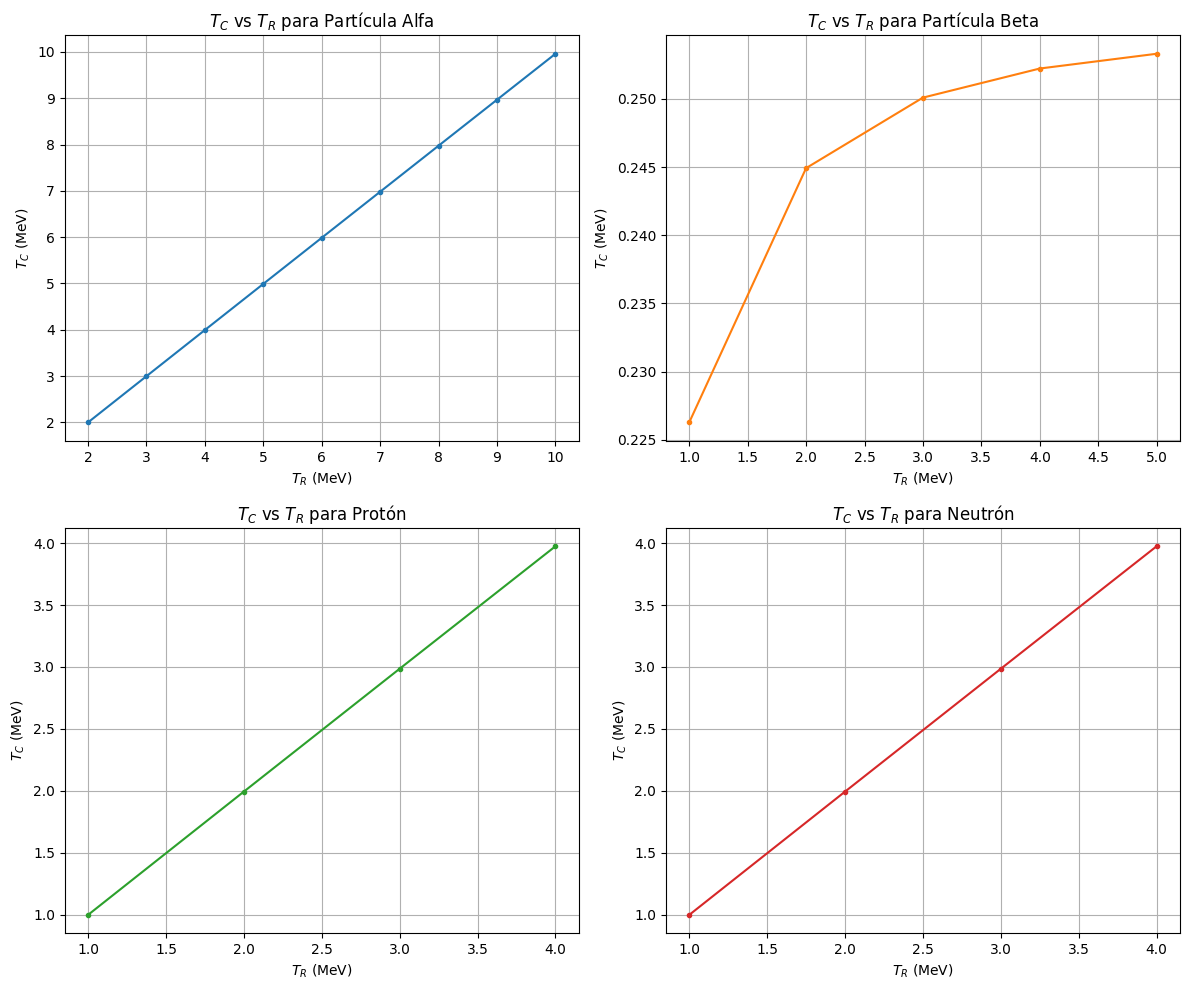

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

paneles = [
    (axs[0, 0], T_R_alpha, T_C_alpha, 'Partícula Alfa', 'tab:blue'),
    (axs[0, 1], T_R_beta, T_C_beta, 'Partícula Beta', 'tab:orange'),
    (axs[1, 0], T_R_proton_neutron, T_C_proton, 'Protón', 'tab:green'),
    (axs[1, 1], T_R_proton_neutron, T_C_neutron, 'Neutrón', 'tab:red'),
]

for ax, T_R, T_C, titulo, color in paneles:
    ax.plot(T_R, T_C, marker='.', color=color)
    ax.set_xlabel('$T_R$ (MeV)')
    ax.set_ylabel('$T_C$ (MeV)')
    ax.set_title(f'$T_C$ vs $T_R$ para {titulo}')
    ax.grid(True)

plt.tight_layout()
plt.show()


### 8.3 Variación de $T_R/T_C$

In [12]:
tabla_razones = [
    ['Partícula Alfa', np.array2string(razon_alpha, precision=6)],
    ['Partícula Beta', np.array2string(razon_beta, precision=6)],
    ['Protón', np.array2string(razon_proton, precision=6)],
    ['Neutrón', np.array2string(razon_neutron, precision=6)],
]
print(tabulate(tabla_razones, headers=['Partícula', 'T_R / T_C']))


Partícula       T_R / T_C
--------------  ------------------------------------------------------------------------
Partícula Alfa  [1.000805 1.001207 1.00161  1.002013 1.002415 1.002818 1.003221 1.003623
                 1.004026]
Partícula Beta  [ 4.419342  8.165991 11.995809 15.859114 19.739223]
Protón          [1.001599 1.003199 1.004799 1.006399]
Neutrón         [1.001597 1.003194 1.004792 1.00639 ]


## 9. Análisis de resultados

Las gráficas y la tabla de razones $T_R/T_C$ muestran cómo la discrepancia entre la energía cinética clásica y la real depende fuertemente de la masa en reposo de la partícula:

1. **Partícula alfa**: con una masa en reposo de aproximadamente 3727 MeV, energías cinéticas de unos pocos MeV representan una perturbación pequeña frente a $m_0c^2$. La partícula se mantiene muy por debajo de la velocidad de la luz, por lo que $T_C$ prácticamente coincide con $T_R$ (razones entre 1.0008 y 1.004).

2. **Partícula beta (electrón)**: su masa en reposo es solo 0.511 MeV, de modo que energías cinéticas de 1 a 5 MeV ya son varias veces mayores que $m_0c^2$: la partícula se mueve a velocidades muy cercanas a $c$. En este régimen $T_C$ se acerca a su valor de saturación $\tfrac{1}{2}m_0c^2$ mientras que $T_R$ sigue creciendo, y la razón $T_R/T_C$ aumenta rápidamente (de 4.4 a 19.7 en el rango estudiado).

3. **Protón y neutrón**: al tener masas en reposo similares entre sí (938 y 940 MeV, respectivamente) y considerablemente mayores que las energías cinéticas consideradas (1 a 4 MeV), su comportamiento es casi idéntico y cercano al límite no relativista, con razones ligeramente superiores a 1.

En conjunto, los resultados confirman que la relación entre masa en reposo y energía cinética —no la energía cinética por sí sola— es lo que determina cuán relevantes son los efectos relativistas: cuanto menor es $m_0c^2$ frente a $T_R$, antes se manifiesta la divergencia entre la predicción clásica y la relativista, hasta el punto de que la fórmula clásica deja de tener sentido físico como estimador de la energía cinética real.


## Referencias

- Einstein, A. (1905). Zur Elektrodynamik bewegter Körper. *Annalen der Physik*, 322(10), 891–921. https://doi.org/10.1002/andp.19053221004
- Krane, K. S. (2012). *Modern Physics* (3rd ed.). Wiley.
- Navas, S., et al. (Particle Data Group). (2024). Review of Particle Physics. *Physical Review D*, 110, 030001. https://doi.org/10.1103/PhysRevD.110.030001
- Serway, R. A., & Jewett, J. W. (2014). *Physics for Scientists and Engineers with Modern Physics* (9th ed.). Cengage Learning.
- Tiesinga, E., Mohr, P. J., Newell, D. B., & Taylor, B. N. (2021). CODATA recommended values of the fundamental physical constants: 2018. *Reviews of Modern Physics*, 93(2), 025010. https://doi.org/10.1103/RevModPhys.93.025010
- Wikipedia. (s.f.). *Anexo:Tabla de partículas*. Recuperado de https://es.wikipedia.org/wiki/Anexo:Tabla_de_part%C3%ADculas (fuente complementaria, usada únicamente para partículas no incluidas en la Review of Particle Physics).
